# Modelo 1: Probabilidad de Acceso a 1ª Preferencia Universitaria

Predice si un estudiante logra matricularse en su **primera preferencia** universitaria usando ArchivoC (perfil académico), ArchivoD (postulaciones 2026) y Oferta Académica (características de la carrera).

In [11]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib, json, os

sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1. Carga de Datos

Se utilizan las tres fuentes oficiales del proceso de admisión DEMRE 2026.

In [12]:
# ─────────────────────────────────────────────────────────────────────────
# FUENTE DE DATOS: base maestra pre-procesada por ETL_EDA_Admision2026.ipynb
# Ejecutar ese notebook primero para generar el archivo parquet.
# ─────────────────────────────────────────────────────────────────────────
import os

RUTA_MAESTRO = '../data/processed/ArchivoC_2026_limpia.parquet'
assert os.path.exists(RUTA_MAESTRO), (
    f'No se encontró {RUTA_MAESTRO}. '
    'Ejecuta primero ETL_EDA_Admision2026.ipynb para generar la base maestra.'
)

# ArchivoC: perfil limpio (rescate y flags ya aplicados)
df_c = pl.read_parquet(RUTA_MAESTRO)

# ArchivoD: preferencias (sólo 1ª preferencia)
cols_d = ['ID_aux','ORDEN_PREF','COD_CARRERA_PREF','ESTADO_PREF','TIPO_PREF','PTJE_PREF']
df_d1 = (pl.read_csv('../data/raw/ArchivoD_Adm2026REG.csv',
                     separator=';', encoding='utf8-lossy', columns=cols_d)
           .filter(pl.col('ORDEN_PREF') == 1))

# Oferta Académica
df_oferta = pl.read_csv('../data/raw/OfertaAcadémica_Admisión2026.csv',
                        separator=';', encoding='utf8-lossy',
                        null_values=['NA',''], infer_schema_length=10000,
                        columns=['CODIGO_CARRERA','PONDERADO_MINIMO',
                                 'VACANTES_1SEM','EXIGE_MATE2'])

print(f'ArchivoC (base maestra limpia): {df_c.shape}')
print(f'ArchivoD (1ª preferencia):      {df_d1.shape}')
print(f'Oferta Académica:               {df_oferta.shape}')
print(f'\nNulos en CLEC:  {df_c["CLEC_REG_ACTUAL"].null_count()}')
print(f'Nulos en MATE1: {df_c["MATE1_REG_ACTUAL"].null_count()}')

ArchivoC (base maestra limpia): (269142, 17)
ArchivoD (1ª preferencia):      (227701, 6)
Oferta Académica:               (2150, 4)

Nulos en CLEC:  0
Nulos en MATE1: 0


## 2. Construcción del Dataset de Modelado

Los datos de ArchivoC ya llegan **limpios** desde la base maestra.
Solo se procesa el target, se calcula el margen de puntaje y se realizan los joins.


In [13]:
# Target y limpieza de ArchivoD
df_d1 = df_d1.with_columns(
    (pl.col('ESTADO_PREF') == 24).cast(pl.Int32).alias('ACCESO_1PREF'),
    pl.col('PTJE_PREF').str.replace_all(',','.').cast(pl.Float64, strict=False)
)

# Joins
df = df_c.join(df_d1, on='ID_aux', how='inner')
df_oferta = df_oferta.with_columns(pl.col('CODIGO_CARRERA').cast(pl.Int64))
df = df.join(df_oferta, left_on='COD_CARRERA_PREF', right_on='CODIGO_CARRERA', how='left')

n_acc = df['ACCESO_1PREF'].sum()
print(f'Dataset final: {df.shape}')
print(f'Con acceso a 1ª pref: {n_acc:,} ({n_acc/df.height*100:.1f}%)')
print(f'Sin acceso:           {df.height-n_acc:,} ({(1-n_acc/df.height)*100:.1f}%)')
print(f'Nulos en CLEC tras joins: {df["CLEC_REG_ACTUAL"].null_count()}')


Dataset final: (226577, 26)
Con acceso a 1ª pref: 75,358 (33.3%)
Sin acceso:           151,219 (66.7%)
Nulos en CLEC tras joins: 0


## 3. Análisis Exploratorio

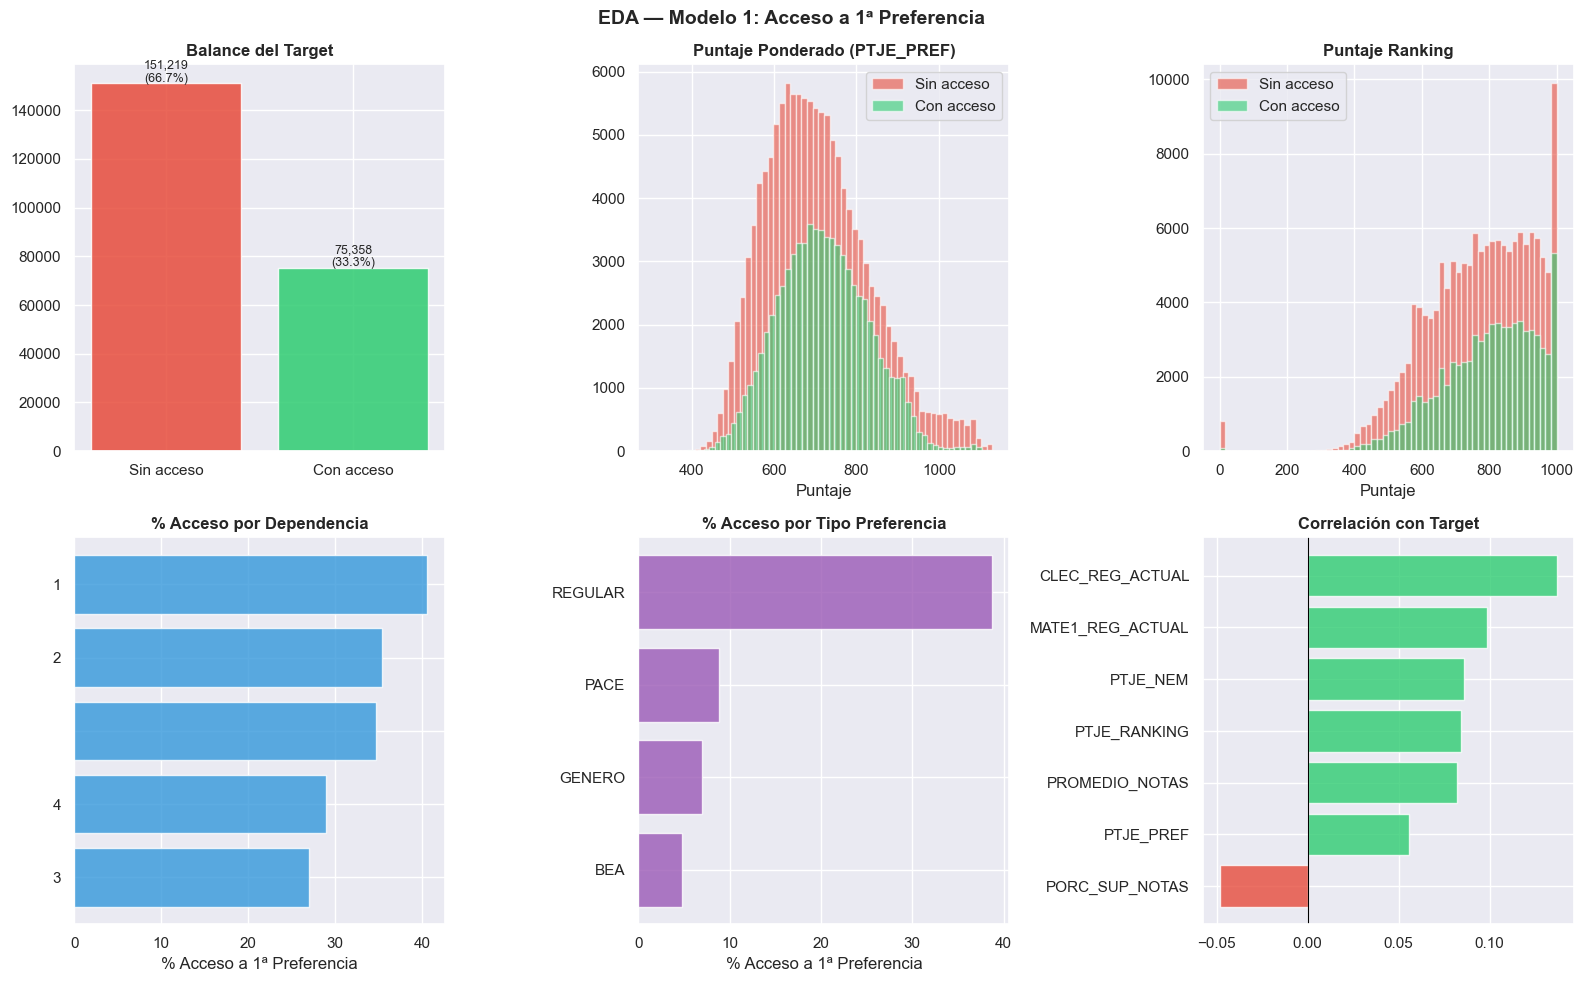

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Balance
tc = df['ACCESO_1PREF'].value_counts().sort('ACCESO_1PREF')
bars = axes[0,0].bar(['Sin acceso','Con acceso'], tc['count'].to_list(),
                     color=['#e74c3c','#2ecc71'], alpha=0.85, edgecolor='white')
for bar, v in zip(bars, tc['count'].to_list()):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                   f'{v:,}\n({v/df.height*100:.1f}%)', ha='center', fontsize=9)
axes[0,0].set_title('Balance del Target', fontweight='bold')

# PTJE_PREF por resultado
for v, c, lbl in [(0,'#e74c3c','Sin acceso'),(1,'#2ecc71','Con acceso')]:
    d = df.filter(pl.col('ACCESO_1PREF')==v)['PTJE_PREF'].drop_nulls().to_numpy()
    axes[0,1].hist(d, bins=60, alpha=0.6, color=c, label=lbl)
axes[0,1].set_title('Puntaje Ponderado (PTJE_PREF)', fontweight='bold')
axes[0,1].legend(); axes[0,1].set_xlabel('Puntaje')

# PTJE_RANKING
for v, c, lbl in [(0,'#e74c3c','Sin acceso'),(1,'#2ecc71','Con acceso')]:
    d = df.filter(pl.col('ACCESO_1PREF')==v)['PTJE_RANKING'].drop_nulls().to_numpy()
    axes[0,2].hist(d, bins=60, alpha=0.6, color=c, label=lbl)
axes[0,2].set_title('Puntaje Ranking', fontweight='bold')
axes[0,2].legend(); axes[0,2].set_xlabel('Puntaje')

# Tasa por dependencia
dep = (df.group_by('GRUPO_DEPENDENCIA')
         .agg((pl.col('ACCESO_1PREF').mean()*100).alias('tasa'))
         .sort('tasa'))
axes[1,0].barh(dep['GRUPO_DEPENDENCIA'].cast(pl.Utf8).to_list(),
               dep['tasa'].to_list(), color='#3498db', alpha=0.8)
axes[1,0].set_title('% Acceso por Dependencia', fontweight='bold')
axes[1,0].set_xlabel('% Acceso a 1ª Preferencia')

# Tasa por TIPO_PREF
tipo = (df.group_by('TIPO_PREF')
          .agg((pl.col('ACCESO_1PREF').mean()*100).alias('tasa'))
          .sort('tasa'))
axes[1,1].barh(tipo['TIPO_PREF'].to_list(), tipo['tasa'].to_list(),
               color='#9b59b6', alpha=0.8)
axes[1,1].set_title('% Acceso por Tipo Preferencia', fontweight='bold')
axes[1,1].set_xlabel('% Acceso a 1ª Preferencia')

# Correlación
num_c = ['PTJE_NEM','PTJE_RANKING','CLEC_REG_ACTUAL','MATE1_REG_ACTUAL',
         'PTJE_PREF','PROMEDIO_NOTAS','PORC_SUP_NOTAS','ACCESO_1PREF']
corr = df.select(num_c).to_pandas().corr()['ACCESO_1PREF'].drop('ACCESO_1PREF').sort_values()
clrs = ['#e74c3c' if v<0 else '#2ecc71' for v in corr.values]
axes[1,2].barh(corr.index, corr.values, color=clrs, alpha=0.8)
axes[1,2].axvline(0, color='k', lw=0.8)
axes[1,2].set_title('Correlación con Target', fontweight='bold')

plt.suptitle('EDA — Modelo 1: Acceso a 1ª Preferencia', fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/eda_modelo1.png', bbox_inches='tight')
plt.show()

## 4. Feature Engineering

Creamos variables derivadas que capturan información contextual clave:
- `MARGEN_PUNTAJE`: diferencia entre el puntaje ponderado real del estudiante y el mínimo exigido por la carrera. **Es el predictor más directo de acceso.**
- `TIENE_MATE2`: si rindió la prueba optativa de Matemática 2.
- `ES_REINTENTO`: si ya había rendido la PAES en un proceso anterior.

In [15]:
df = df.with_columns([
    (pl.col('PTJE_PREF') - pl.col('PONDERADO_MINIMO')).alias('MARGEN_PUNTAJE'),
    # ES_REINTENTO: si RINDIO_PROCESO_ACTUAL == 0, el estudiante usa puntaje de año anterior
    (pl.col('RINDIO_PROCESO_ACTUAL') == 0).cast(pl.Int32).alias('ES_REINTENTO'),
    pl.col('VACANTES_1SEM').cast(pl.Float64, strict=False),
])

features_num = ['PTJE_NEM','PTJE_RANKING','CLEC_REG_ACTUAL','MATE1_REG_ACTUAL',
                'MATE2_REG_ACTUAL','HCSOC_REG_ACTUAL','CIEN_REG_ACTUAL',
                'PROMEDIO_NOTAS','PORC_SUP_NOTAS','PTJE_PREF',
                'MARGEN_PUNTAJE','VACANTES_1SEM','TIENE_MATE2','ES_REINTENTO']
features_cat = ['GRUPO_DEPENDENCIA','CODIGO_REGION','RAMA_EDUCACIONAL','TIPO_PREF']

df_model = df.select(features_num + features_cat + ['ACCESO_1PREF']).to_pandas()
df_model[features_num] = df_model[features_num].apply(pd.to_numeric, errors='coerce')

print(f'Dataset para modelado: {df_model.shape}')
print(f'Nulos por feature (top 8):')
print(df_model.isnull().sum().sort_values(ascending=False).head(8))


Dataset para modelado: (226577, 19)
Nulos por feature (top 8):
MARGEN_PUNTAJE      161006
MATE2_REG_ACTUAL    110358
HCSOC_REG_ACTUAL    103040
CIEN_REG_ACTUAL      50339
PTJE_PREF            18807
TIENE_MATE2              0
TIPO_PREF                0
RAMA_EDUCACIONAL         0
dtype: int64


## 5. Pipeline de Preprocesamiento

Estrategia:
- **Numéricas**: imputación por mediana (no por 0, que sesgaría el modelo) + estandarización.
- **Categóricas**: imputación con constante + OneHotEncoding.

In [16]:
X = df_model[features_num + features_cat]
y = df_model['ACCESO_1PREF'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Prevalencia train: {y_train.mean()*100:.2f}% | test: {y_test.mean()*100:.2f}%')

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), features_num),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='desconocido')),
        ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), features_cat)
])

modelos = {
    'Regresión Logística': Pipeline([('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, C=0.1,
                                   class_weight='balanced', random_state=42))]),
    'Random Forest': Pipeline([('prep', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=12,
                                       class_weight='balanced',
                                       random_state=42, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('prep', preprocessor),
        ('clf', HistGradientBoostingClassifier(max_iter=200, max_depth=6,
                                               class_weight='balanced',
                                               random_state=42))]),
}
print('✅ Pipelines configurados')

Train: 181,261 | Test: 45,316
Prevalencia train: 33.26% | test: 33.26%
✅ Pipelines configurados


## 6. Entrenamiento y Comparación de Modelos

Validación cruzada estratificada de 5 folds sobre el conjunto de entrenamiento.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc','f1','precision','recall']
resultados = {}

print('Entrenando modelos con CV 5-fold estratificado...\n')
for nombre, pipeline in modelos.items():
    print(f'  → {nombre}...')
    cvr = cross_validate(pipeline, X_train, y_train, cv=cv,
                         scoring=scoring, n_jobs=-1)
    resultados[nombre] = {
        'AUC-ROC': cvr['test_roc_auc'].mean(),
        'AUC±std':  cvr['test_roc_auc'].std(),
        'F1':       cvr['test_f1'].mean(),
        'Precisión':cvr['test_precision'].mean(),
        'Recall':   cvr['test_recall'].mean(),
    }
    print(f'     AUC-ROC: {resultados[nombre]["AUC-ROC"]:.4f} ± {resultados[nombre]["AUC±std"]:.4f}')
    print(f'     F1:      {resultados[nombre]["F1"]:.4f}')

df_res = pd.DataFrame(resultados).T
print('\n' + '='*55)
print('RESULTADOS CV — COMPARACIÓN DE MODELOS')
print('='*55)
print(df_res[['AUC-ROC','F1','Precisión','Recall']].round(4).to_string())

Entrenando modelos con CV 5-fold estratificado...

  → Regresión Logística...


/Users/pabloignaciocortesvielma/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pabloignaciocortesvielma/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pabloignaciocortesvielma/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pabloignaciocortesvielma/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pabloignaciocortesvielma/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encounte

     AUC-ROC: 0.7474 ± 0.0009
     F1:      0.5832
  → Random Forest...
     AUC-ROC: 0.8310 ± 0.0015
     F1:      0.6618
  → Gradient Boosting...
     AUC-ROC: 0.9039 ± 0.0016
     F1:      0.7449

RESULTADOS CV — COMPARACIÓN DE MODELOS
                     AUC-ROC      F1  Precisión  Recall
Regresión Logística   0.7474  0.5832     0.4860  0.7289
Random Forest         0.8310  0.6618     0.5416  0.8504
Gradient Boosting     0.9039  0.7449     0.6562  0.8613


## 7. Evaluación Final en Conjunto de Test

Mejor modelo: Gradient Boosting



=== Reporte de Clasificación ===
              precision    recall  f1-score   support

  Sin Acceso       0.92      0.77      0.84     30244
  Con Acceso       0.66      0.86      0.75     15072

    accuracy                           0.80     45316
   macro avg       0.79      0.82      0.79     45316
weighted avg       0.83      0.80      0.81     45316

AUC-ROC (test): 0.9052


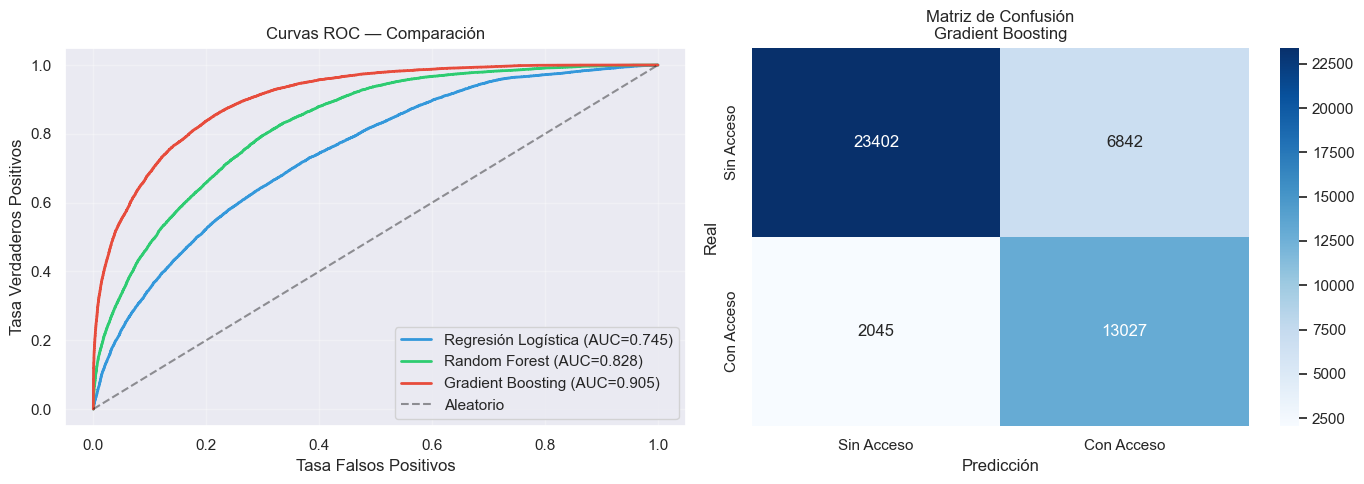

In [18]:
mejor_nombre = df_res['AUC-ROC'].idxmax()
mejor_pipeline = modelos[mejor_nombre]
print(f'Mejor modelo: {mejor_nombre}\n')
mejor_pipeline.fit(X_train, y_train)
y_pred  = mejor_pipeline.predict(X_test)
y_proba = mejor_pipeline.predict_proba(X_test)[:, 1]

print('=== Reporte de Clasificación ===')
print(classification_report(y_test, y_pred, target_names=['Sin Acceso','Con Acceso']))
auc_final = roc_auc_score(y_test, y_proba)
print(f'AUC-ROC (test): {auc_final:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_m = ['#3498db','#2ecc71','#e74c3c']
for (nm, pipe), col in zip(modelos.items(), colors_m):
    if nm != mejor_nombre:
        pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f'{nm} (AUC={roc_auc_score(y_test,p):.3f})',
                 color=col, lw=2)
axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='Aleatorio')
axes[0].set(xlabel='Tasa Falsos Positivos', ylabel='Tasa Verdaderos Positivos',
            title='Curvas ROC — Comparación')
axes[0].legend(); axes[0].grid(alpha=0.3)

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', ax=axes[1],
            xticklabels=['Sin Acceso','Con Acceso'],
            yticklabels=['Sin Acceso','Con Acceso'])
axes[1].set(title=f'Matriz de Confusión\n{mejor_nombre}',
            xlabel='Predicción', ylabel='Real')
plt.tight_layout()
plt.savefig('../reports/figures/evaluacion_modelo1.png', bbox_inches='tight')
plt.show()

## 8. Importancia de Variables

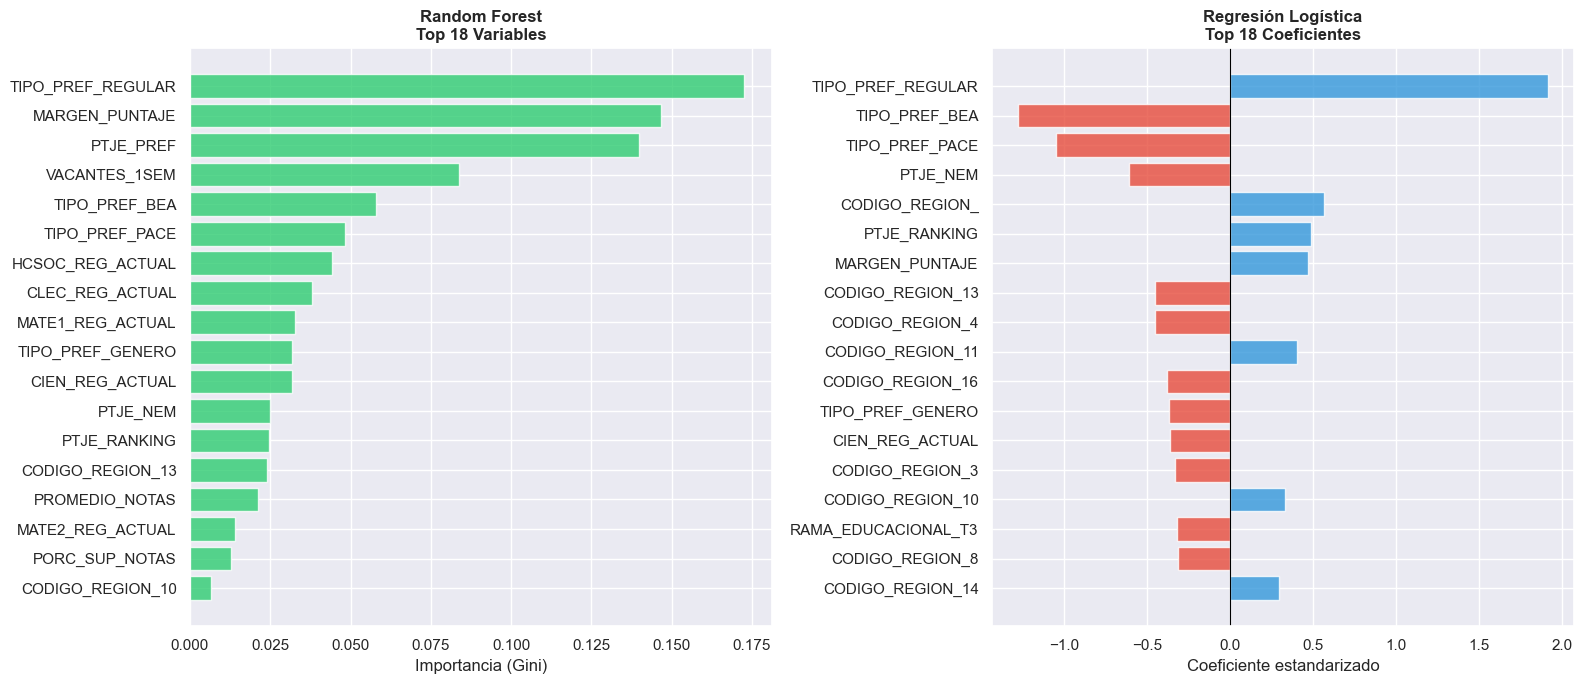

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top_n = 18

# Random Forest
rf_pipe = modelos['Random Forest']
rf_clf  = rf_pipe.named_steps['clf']
rf_prep = rf_pipe.named_steps['prep']
ohe_feats = rf_prep.named_transformers_['cat']['enc'].get_feature_names_out(features_cat)
all_feats = np.array(features_num + list(ohe_feats))
imps = rf_clf.feature_importances_
idx  = np.argsort(imps)[-top_n:]
axes[0].barh(all_feats[idx], imps[idx], color='#2ecc71', alpha=0.8, edgecolor='white')
axes[0].set_title(f'Random Forest\nTop {top_n} Variables', fontweight='bold')
axes[0].set_xlabel('Importancia (Gini)')

# Logistic Regression
lr_pipe = modelos['Regresión Logística']
lr_clf  = lr_pipe.named_steps['clf']
lr_prep = lr_pipe.named_steps['prep']
lr_ohe  = lr_prep.named_transformers_['cat']['enc'].get_feature_names_out(features_cat)
lr_feats = np.array(features_num + list(lr_ohe))
coefs = lr_clf.coef_[0]
idx_lr = np.argsort(np.abs(coefs))[-top_n:]
clrs = ['#e74c3c' if v<0 else '#3498db' for v in coefs[idx_lr]]
axes[1].barh(lr_feats[idx_lr], coefs[idx_lr], color=clrs, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_title(f'Regresión Logística\nTop {top_n} Coeficientes', fontweight='bold')
axes[1].set_xlabel('Coeficiente estandarizado')

plt.tight_layout()
plt.savefig('../reports/figures/importancia_modelo1.png', bbox_inches='tight')
plt.show()

## 9. Exportación del Modelo

Se exporta el mejor pipeline completo (preprocesador + clasificador) y sus metadatos para uso en el dashboard Streamlit.

In [20]:
os.makedirs('../models', exist_ok=True)
joblib.dump(mejor_pipeline, '../models/modelo_acceso.joblib')

metadata = {
    'modelo': mejor_nombre,
    'features_num': features_num,
    'features_cat': features_cat,
    'target': 'ACCESO_1PREF',
    'descripcion_target': 'P(matricula en 1a preferencia) | ESTADO_PREF==24',
    'auc_roc_cv': float(df_res.loc[mejor_nombre, 'AUC-ROC']),
    'auc_roc_test': float(auc_final),
    'n_train': int(X_train.shape[0]),
    'n_test':  int(X_test.shape[0]),
}
with open('../models/modelo_acceso_metadata.json','w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print('✅ Modelo exportado → ../models/modelo_acceso.joblib')
print('✅ Metadata exportada → ../models/modelo_acceso_metadata.json')
print(f'\n📊 Resumen:')
print(f'   Modelo:         {mejor_nombre}')
print(f'   AUC-ROC (CV):   {df_res.loc[mejor_nombre, "AUC-ROC"]:.4f}')
print(f'   AUC-ROC (test): {auc_final:.4f}')
print(f'   Dataset:        {df_model.shape[0]:,} postulantes | {len(features_num+features_cat)} features')

✅ Modelo exportado → ../models/modelo_acceso.joblib
✅ Metadata exportada → ../models/modelo_acceso_metadata.json

📊 Resumen:
   Modelo:         Gradient Boosting
   AUC-ROC (CV):   0.9039
   AUC-ROC (test): 0.9052
   Dataset:        226,577 postulantes | 18 features
